# Aula 02 - Aprendizagem de Máquina (Parte I)

## Pré-processamento de dados

In [1]:
from __future__ import division
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

filename = '../files/lending_club_loans.csv'
df = pd.read_csv(filename, low_memory=False)
col_names = df.columns.tolist()
print (col_names)
print ('Number of attributes: ' + str(len(col_names)))

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

Estudo de caso: queremos prever com base nas informações preenchidas pelo cliente que está solicitando um empréstimo se ele será concedido ou não até certo limite. Usaremos dados do Lending Club. 

Podemos usar o data set para tentar prever empréstimos aceitos com sucesso. Um pedido de empréstimo é bem-sucedido se o valor financiado (funded_amnt) ou o valor financiado pelos investidores (funded_amnt_inv) for próximo ao valor do empréstimo (loan_amnt) solicitado. Nesse sentido, poderíamos colocar um limite no qual a aceitação é baseada como a fórmula: 
$$\frac{loan - funded}{loan}\geq 0.5$$

Apagar as colunas que não são úteis para nosso estudo.

In [2]:
drop_cols = ['id', 'member_id', 'grade', 'sub_grade','earliest_cr_line', 'emp_title', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'inq_last_6mths', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code']

In [3]:
df = df.drop(drop_cols,axis=1)

In [4]:
col_names = df.columns.tolist()
col_names

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'mths_since_last_delinq',
 'total_acc',
 'last_fico_range_high',
 'last_fico_range_low',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_il_6m',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mths_since_recent_revol_del

Checar as features (atributos)

In [5]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,dti,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,5000.0,5000.0,4975.0,36 months,0.1065,162.87,10+ years,RENT,24000.0,27.65,...,NaN,NaN,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN
1,2500.0,2500.0,2500.0,60 months,0.1527,59.83,< 1 year,RENT,30000.0,1.00,...,NaN,NaN,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN
2,2400.0,2400.0,2400.0,36 months,0.1596,84.33,10+ years,RENT,12252.0,8.72,...,NaN,NaN,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN
3,10000.0,10000.0,10000.0,36 months,0.1349,339.31,10+ years,RENT,49200.0,20.00,...,NaN,NaN,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN
4,3000.0,3000.0,3000.0,60 months,0.1269,67.79,1 year,RENT,80000.0,17.94,...,NaN,NaN,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN


Observe as features term, emp_length, home_ownership. 

term e emp_length e emp_length são strings, podemos usar várias estratégias para processá-las: podemos vetorizar os diferentes resultados. Mas observe que existe uma relação de ordem. Nesse caso específico, os valores categóricos podem ser traduzidos diretamente em números que representam essa ordem. Finalmente, house_ownership será vetorizado em tantos recursos quantos forem os valores na variável categórica.

In [6]:
def clear_term (row):
    try:
        if row['term']==' 36 months':
            d = 1
        else:
            if row['term']==' 60 months':
                d = 2
            else:
                if np.isnan(row['term']):
                    d = None
                else:
                    print ('WRONG')
                    print (row['term'])
    except:
        print ('EXCEPT')
        d = None
    return d

df['term_clean'] = df.apply (lambda row: clear_term(row),axis=1)
    

In [7]:
df['term_clean']

0        1.0
1        2.0
2        1.0
3        1.0
4        2.0
5        1.0
6        2.0
7        1.0
8        2.0
9        2.0
10       2.0
11       1.0
12       1.0
13       1.0
14       1.0
15       1.0
16       1.0
17       1.0
18       1.0
19       1.0
20       2.0
21       1.0
22       1.0
23       1.0
24       1.0
25       1.0
26       1.0
27       2.0
28       1.0
29       1.0
        ... 
42508    1.0
42509    1.0
42510    1.0
42511    1.0
42512    1.0
42513    1.0
42514    1.0
42515    1.0
42516    1.0
42517    1.0
42518    1.0
42519    1.0
42520    1.0
42521    1.0
42522    1.0
42523    1.0
42524    1.0
42525    1.0
42526    1.0
42527    1.0
42528    1.0
42529    1.0
42530    1.0
42531    1.0
42532    1.0
42533    1.0
42534    1.0
42535    1.0
42536    NaN
42537    NaN
Name: term_clean, Length: 42538, dtype: float64

In [8]:
#Usaremos um dicionário para fazer o mapeamento
def clean_emp_length(argument):
    switcher = {
        '1 year': 1,
        '2 years': 2,
        '3 years': 3,
        '4 years': 4,
        '5 years': 5,
        '6 years': 6,
        '7 years': 7,
        '8 years': 8,
        '9 years': 9,
        '10+ years': 10,
        '< 1 year': 0,
        'n/a':None,
    }
    try:
        d = switcher[argument['emp_length']]    
    except:
        d = None
    return d

df['emp_length_clean'] = df.apply (lambda row: clean_emp_length(row),axis=1)


In [9]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,dti,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,term_clean,emp_length_clean
0,5000.0,5000.0,4975.0,36 months,0.1065,162.87,10+ years,RENT,24000.0,27.65,...,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN,1.0,10.0
1,2500.0,2500.0,2500.0,60 months,0.1527,59.83,< 1 year,RENT,30000.0,1.00,...,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN,2.0,0.0
2,2400.0,2400.0,2400.0,36 months,0.1596,84.33,10+ years,RENT,12252.0,8.72,...,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN,1.0,10.0
3,10000.0,10000.0,10000.0,36 months,0.1349,339.31,10+ years,RENT,49200.0,20.00,...,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN,1.0,10.0
4,3000.0,3000.0,3000.0,60 months,0.1269,67.79,1 year,RENT,80000.0,17.94,...,NaN,NaN,0.0,False,NaN,NaN,NaN,NaN,2.0,1.0


In [10]:
from sklearn.feature_extraction import DictVectorizer

comb_dict = df[['home_ownership']].to_dict(orient='records')
vec = DictVectorizer()
home = 2*vec.fit_transform(comb_dict).toarray()-1
home[:5]

array([[-1., -1., -1., -1., -1.,  1.],
       [-1., -1., -1., -1., -1.,  1.],
       [-1., -1., -1., -1., -1.,  1.],
       [-1., -1., -1., -1., -1.,  1.],
       [-1., -1., -1., -1., -1.,  1.]])

In [11]:
df_vector = pd.DataFrame(home[:,1:])
vector_columns = vec.get_feature_names()
df_vector.columns = vector_columns[1:]
df_vector.index = df.index
df_vector


,home_ownership=MORTGAGE,home_ownership=NONE,home_ownership=OTHER,home_ownership=OWN,home_ownership=RENT
0,-1.0,-1.0,-1.0,-1.0,1.0
1,-1.0,-1.0,-1.0,-1.0,1.0
2,-1.0,-1.0,-1.0,-1.0,1.0
3,-1.0,-1.0,-1.0,-1.0,1.0
4,-1.0,-1.0,-1.0,-1.0,1.0
5,-1.0,-1.0,-1.0,-1.0,1.0
6,-1.0,-1.0,-1.0,-1.0,1.0
7,-1.0,-1.0,-1.0,-1.0,1.0
8,-1.0,-1.0,-1.0,1.0,-1.0
9,-1.0,-1.0,-1.0,-1.0,1.0


In [12]:
#Juntar os dados
df = df.join(df_vector)
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,dti,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,term_clean,emp_length_clean,home_ownership=MORTGAGE,home_ownership=NONE,home_ownership=OTHER,home_ownership=OWN,home_ownership=RENT
0,5000.0,5000.0,4975.0,36 months,0.1065,162.87,10+ years,RENT,24000.0,27.65,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
1,2500.0,2500.0,2500.0,60 months,0.1527,59.83,< 1 year,RENT,30000.0,1.00,...,NaN,NaN,NaN,2.0,0.0,-1.0,-1.0,-1.0,-1.0,1.0
2,2400.0,2400.0,2400.0,36 months,0.1596,84.33,10+ years,RENT,12252.0,8.72,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
3,10000.0,10000.0,10000.0,36 months,0.1349,339.31,10+ years,RENT,49200.0,20.00,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
4,3000.0,3000.0,3000.0,60 months,0.1269,67.79,1 year,RENT,80000.0,17.94,...,NaN,NaN,NaN,2.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0


In [13]:
#Apagar as colunas processadas
df = df.drop(['term','int_rate','emp_length','home_ownership'],axis=1)
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,mths_since_last_delinq,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,term_clean,emp_length_clean,home_ownership=MORTGAGE,home_ownership=NONE,home_ownership=OTHER,home_ownership=OWN,home_ownership=RENT
0,5000.0,5000.0,4975.0,162.87,24000.0,27.65,0.0,735.0,739.0,NaN,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
1,2500.0,2500.0,2500.0,59.83,30000.0,1.00,0.0,740.0,744.0,NaN,...,NaN,NaN,NaN,2.0,0.0,-1.0,-1.0,-1.0,-1.0,1.0
2,2400.0,2400.0,2400.0,84.33,12252.0,8.72,0.0,735.0,739.0,NaN,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
3,10000.0,10000.0,10000.0,339.31,49200.0,20.00,0.0,690.0,694.0,35.0,...,NaN,NaN,NaN,1.0,10.0,-1.0,-1.0,-1.0,-1.0,1.0
4,3000.0,3000.0,3000.0,67.79,80000.0,17.94,0.0,695.0,699.0,38.0,...,NaN,NaN,NaN,2.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0


## Aprendizagem de Máquina Supervisionada - Classificação

Aprendizagem de Máquina (AM) é a ciência (ou a arte) de criar sistemas que podem aprender com base em um **conjunto de dados** (treinamento). Uma definição mais generalista descreve AM como "o campo de estudos que fornece aos computadores a habilidade de aprender sem serem explicitamente programados".

Os sistemas de AM podem ser classificados de acordo com a **quantidade e o tipo de supervisão** que recebem durante o treinamento. Existem três categorias principais: aprendizagem supervisionada, aprendizagem não supervisionada, e aprendizagem semi-supervisionada ou por reforço.

Na aprendizagem supervisionada, o algoritmo "aprende" ou reconhece padrões com base em exemplos. Na classificação, o algoritmo, também chamado de classificador, reconhece o padrão de um conjunto de dados para prever o valor de um atributo especial denominado classe.

Na **aprendizagem supervisionada**, o algoritmo "aprende" ou reconhece padrões com base em dados de treinamento. Os dados que você utiliza para treinar o algoritmo incluem um atributo especial que classifica cada instância do conjunto de dados, chamado de classe ou rótulo. Uma atividade típica da aprendizagem supervisionada é a **classificação**. O filtro de spam é um bom exemplo desta técnica: ele é treinado com muitos e-mails de exemplo, e cada um deles possui a sua classe (spam ou não-spam), e o sistema precisa aprender a classificar novos e-mails com base no conjunto de treinamento.

In [14]:
import matplotlib.pylab as plt

%matplotlib inline 
plt.style.use('seaborn-whitegrid')
plt.rc('text', usetex=True)
plt.rc('font', family='times')
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))


**Conjunto de dados de exemplo**: continuaremos a usar os dados sobre financiamento bancário.

In [15]:
import pickle
ofname = open('../files/dataset_small.pkl','rb') 
(x,y) = pickle.load(ofname)

Checar o volume dos dados

In [16]:
dims = x.shape[1]
N = x.shape[0]
print ('atributos: ' + str(dims)+', exemplos: '+ str(N))

atributos: 15, exemplos: 4140


**Vamos construir um classificador simples**

A primeira etapa é o **treinamento**: executar o algoritmo usando o conjunto de dados para que ele "aprenda" a reconhecer o padrão de cada classe. A partir daí, o classificador pode ser usada para perver o resultado sobre dados novos.

In [17]:
from sklearn import neighbors
from sklearn import datasets

#Criar uma instância do algoritmo de classificação KNN (K-nearest neighbor)
knn = neighbors.KNeighborsClassifier(n_neighbors=11)

#Treinar o classificador
knn.fit(x,y)

#Calcular o valor previsto de acordo com o modelo
yhat = knn.predict(x)

#Checar o resultado do último exemplo
print ('Valor previsto: ' + str (yhat [ -1]), ', valor real: ' + str (y [ -1]))

('Valor previsto: -1.0', ', valor real: -1.0')


Verificar a Acurácia: **Número de Previsões Corretas / Total de Previsões**

In [18]:
knn.score(x,y)

0.8316425120772947

A distribuição dos rótulos de predição é dada pelo seguinte gráfico:

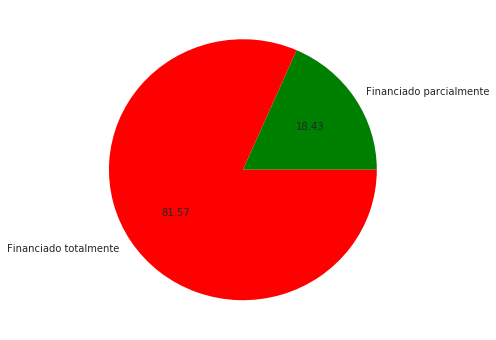

In [19]:
#%matplotlib inline
#import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False  # Desativa LaTeX
import numpy as np
plt.pie(np.c_[np.sum(np.where(y==1,1,0)),np.sum(np.where(y==-1,1,0))][0],
        labels=['Financiado parcialmente','Financiado totalmente'],
        colors=['g','r'],
        shadow=False,
        autopct ='%.2f' )
plt.gcf().set_size_inches((6,6))
plt.savefig("pie.png",dpi=300, bbox_inches='tight')


Calcular a matriz de confusão:
+ TP (verdadeiro positivo): o classificador prevê um exemplo como positivo, e ele realmente é positivo.
+ FP (falso positivo): o classificador prevê um exemplo como positivo, mas ele é negativo.
+ TN (verdadeiro negativo): o classificador prevê um exemplo como negativo, e ele realmente é negativo.
+ FN (falso negativo): o classificador prevê um exemplo como negativo, mas ele é positivo.

In [20]:
yhat = knn.predict(x)
TP = np.sum(np.logical_and(yhat==-1,y==-1))
TN = np.sum(np.logical_and(yhat==1,y==1))
FP = np.sum(np.logical_and(yhat==-1,y==1))
FN = np.sum(np.logical_and(yhat==1,y==-1))
print 'TP: '+ str(TP), ', FP: '+ str(FP)
print 'FN: '+ str(FN), ', TN: '+ str(TN)

TP: 3370 , FP: 690
FN: 7 , TN: 73


In [21]:
from sklearn import metrics
metrics.confusion_matrix(yhat,y)

array([[3370,  690],
       [   7,   73]], dtype=int64)

In [23]:
#Treinamento do classificador com K = 1
from sklearn import neighbors
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(x,y)
yhat=knn.predict(x)

print ("Acuracia do classificador:", metrics.accuracy_score(yhat, y))
print ("Matriz de confusão: \n" + str(metrics.confusion_matrix(yhat, y)))

('Acuracia do classificador:', 1.0)
Matriz de confusão: 
[[3377    0]
 [   0  763]]


Até este ponto utilizamos dados de treinamento para "avaliar" o desempenho do classificador, mas esta é uma prática não recomendada. Vamos usar um subconjunto dos dados de treinamento para **testar** o desempenho do classificador.

A avaliação do desempenho é uma etapa de **validação** do algoritmo.

In [24]:
# Dividindo o dataset em dois conjuntos de dados, se treinamento e de teste.
import numpy as np
perm = np.random.permutation(y.size)
PRC = 0.7
split_point = int(np.ceil(y.shape[0]*PRC))

X_train = x[perm[:split_point].ravel(),:]
y_train = y[perm[:split_point].ravel()]

X_test = x[perm[split_point:].ravel(),:]
y_test = y[perm[split_point:].ravel()]

print ('Dados de entrada do treinamento: ' + str(X_train.shape), ' , resposta do treinamento: '+str(y_train.shape))
print ('Dados de entrada do teste: ' + str(X_test.shape), ' , resposta do teste: '+str(y_test.shape))

('Dados de entrada do treinamento: (2898L, 15L)', ' , resposta do treinamento: (2898L,)')
('Dados de entrada do teste: (1242L, 15L)', ' , resposta do teste: (1242L,)')


In [29]:
#Treinar o classificador com os dados de treinamento
from sklearn import neighbors
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

#Visualizar o desempenho
yhat=knn.predict(X_train)

from sklearn import metrics
print ("\nESTATÍSTICA DO TREINAMENTO:")
print ("Acuracia do classificador:", metrics.accuracy_score(yhat, y_train))
print ("Matriz de confusão: \n"+ str(metrics.confusion_matrix(y_train, yhat)))


ESTATÍSTICA DO TREINAMENTO:
('Acuracia do classificador:', 1.0)
Matriz de confusão: 
[[2346    0]
 [   0  552]]


In [32]:
#Analisar com os dados de teste
yhat=knn.predict(X_test)
print ("ESTATÍSTICAS DO TESTE:")
print ("Acuracia do classificador:", metrics.accuracy_score(yhat, y_test))
print ("Matriz de confusão: \n"+ str(metrics.confusion_matrix(yhat,y_test)))

ESTATÍSTICAS DO TESTE:
('Acuracia do classificador:', 0.7568438003220612)
Matriz de confusão: 
[[877 148]
 [154  63]]


É possível automatizar esse processo, com as ferramentas fornecidas pelo pacote scikit-learn

In [34]:
#Divisão feita com os pacotes fornecidos pelo pacote sklearn:
from sklearn.model_selection import train_test_split
from sklearn import neighbors
from sklearn import metrics

PRC = 0.3
acc = np.zeros((10,))
for i in xrange(10):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=PRC)
    knn = neighbors.KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train,y_train)
    yhat = knn.predict(X_test)
    acc[i] = metrics.accuracy_score(yhat, y_test)
acc.shape=(1,10)
print ("Erro médio: "+str(np.mean(acc[0])))

Erro médio: 0.7595813204508857


Nós podemos usar o processo de validação para a seleção do algoritmo de AM.

Vamos analisar o desempenho de quatro classificadores diferentes sobre o mesmo conjunto de dados.

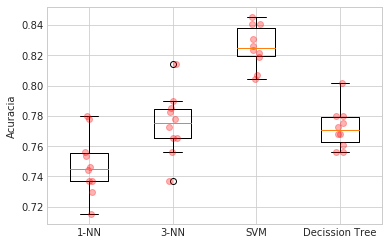

In [35]:
from sklearn.model_selection import train_test_split
from sklearn import neighbors
from sklearn import tree
from sklearn import svm
from sklearn import metrics

PRC = 0.1
acc_r=np.zeros((10,4))
for i in xrange(10):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=PRC)
    nn1 = neighbors.KNeighborsClassifier(n_neighbors=1)
    nn3 = neighbors.KNeighborsClassifier(n_neighbors=3)
    svc = svm.SVC()
    dt = tree.DecisionTreeClassifier()
    
    nn1.fit(X_train,y_train)
    nn3.fit(X_train,y_train)
    svc.fit(X_train,y_train)
    dt.fit(X_train,y_train)
    
    yhat_nn1=nn1.predict(X_test)
    yhat_nn3=nn3.predict(X_test)
    yhat_svc=svc.predict(X_test)
    yhat_dt=dt.predict(X_test)
    
    acc_r[i][0] = metrics.accuracy_score(yhat_nn1, y_test)
    acc_r[i][1] = metrics.accuracy_score(yhat_nn3, y_test)
    acc_r[i][2] = metrics.accuracy_score(yhat_svc, y_test)
    acc_r[i][3] = metrics.accuracy_score(yhat_dt, y_test)


plt.boxplot(acc_r);
for i in xrange(4):
    xderiv = (i+1)*np.ones(acc_r[:,i].shape)+(np.random.rand(10,)-0.5)*0.1
    plt.plot(xderiv,acc_r[:,i],'ro',alpha=0.3)
    
ax = plt.gca()
ax.set_xticklabels(['1-NN','3-NN','SVM','Decission Tree'])
plt.ylabel('Acuracia')

import os
img_path = 'plots/error_ms_1.png'
os.path.exists('plots') or os.makedirs('plots')
os.path.exists(img_path) and os.remove(img_path)
plt.savefig(img_path, dpi=300, bbox_inches='tight')